# Adaptive Neuro-Fuzzy Inference System (ANFIS) for TinyML

This notebook provides a comprehensive, hands-on tutorial for training, evaluating, and deploying Adaptive Neuro-Fuzzy Inference System (ANFIS) models on resource-constrained microcontrollers.

## Covered Topics

1. **Nonlinear Regression** — function approximation with interpretable fuzzy rules
2. **Binary Classification** — decision boundaries on non-convex manifolds
3. **Multiclass Classification** — multi-region partitioning with fuzzy logic
4. **Membership Function Visualization** — inspecting learned linguistic terms
5. **Rule Extraction** — human-readable IF-THEN explanations
6. **Arduino Code Generation** — automated C++ export for AVR and ESP32
7. **Fuzzy Regularization** — enforcing compact, well-separated membership functions

## Reference

Jang, J.-S. R. (1993). ANFIS: Adaptive-Network-Based Fuzzy Inference System. *IEEE Transactions on Systems, Man, and Cybernetics*, 23(3), 665–685.


## 0 — Environment Setup and Imports

Ensure that the `nf_*.py` modules are located in the same directory as this notebook, alongside the original `losses.py` from the LNN framework.


In [1]:
import sys
import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons, make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import json

# ANFIS framework imports
from nf_model import ANFISModel
from nf_utils import (
    train_model,
    plot_training_history,
    plot_membership_functions,
    plot_firing_strengths,
    plot_regression_surface,
    plot_decision_boundary,
    export_to_json,
)
from nf_cpp_generator import generate_ino
from nf_losses import fuzzy_reg_loss

print("Imports successful — PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

os.makedirs('json_model',   exist_ok=True)
os.makedirs('arduino_code', exist_ok=True)


Imports successful — PyTorch version: 2.11.0+cpu
CUDA available: False


---

## 1 — Nonlinear Regression

In this section, an ANFIS model is trained to approximate the two-dimensional nonlinear function

$$y = \sin(x_1) \cdot \cos(x_2)$$

using a Gaussian membership function base with five linguistic terms per input variable (25 fuzzy rules total).


Training set: (320, 2) | Test set: (80, 2)
Target range: [-1.000, 1.079]


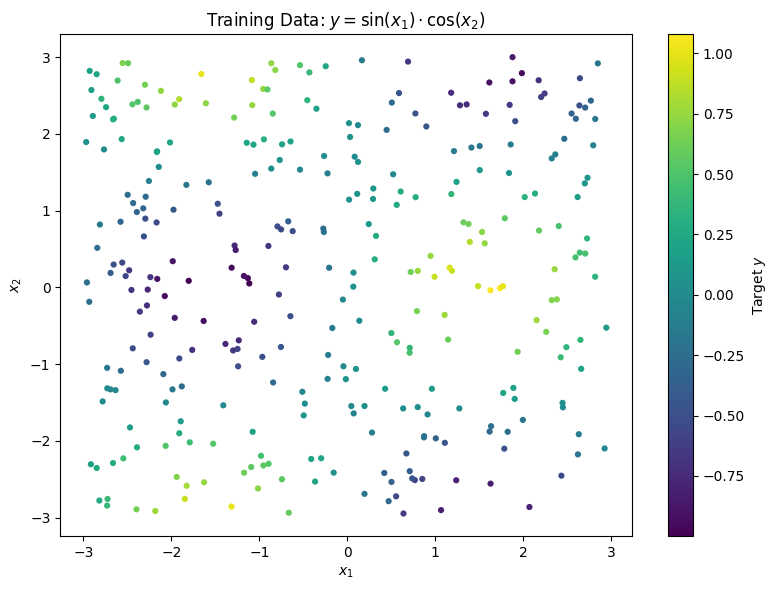

In [2]:
# ============================================================
# 1.1 — Synthetic Dataset Generation
# ============================================================
np.random.seed(42)
n_samples = 400

X = np.random.uniform(-3.0, 3.0, size=(n_samples, 2)).astype(np.float32)
y = np.sin(X[:, 0]) * np.cos(X[:, 1]) + 0.05 * np.random.randn(n_samples)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

print("Training set:", X_train.shape, "| Test set:", X_test.shape)
print("Target range: [{:.3f}, {:.3f}]".format(float(y.min()), float(y.max())))

# Visualize the training distribution
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(),
                cmap='viridis', s=20, edgecolors='none')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title(r'Training Data: $y = \sin(x_1) \cdot \cos(x_2)$')
plt.colorbar(sc, ax=ax, label='Target $y$')
plt.tight_layout()
plt.show()


ANFIS Architecture:
  Input variables : 2
  Terms per input : 5
  Total rules     : 25
  Total parameters: 95
  Epoch     1/1000  |  MSE = 0.413195
  Epoch   100/1000  |  MSE = 0.027649
  Epoch   200/1000  |  MSE = 0.005689
  Epoch   300/1000  |  MSE = 0.004067
  Epoch   400/1000  |  MSE = 0.003367
  Epoch   500/1000  |  MSE = 0.002955
  Epoch   600/1000  |  MSE = 0.002705
  Epoch   700/1000  |  MSE = 0.002553
  Epoch   800/1000  |  MSE = 0.002459
  Epoch   900/1000  |  MSE = 0.002400
  Epoch  1000/1000  |  MSE = 0.002360


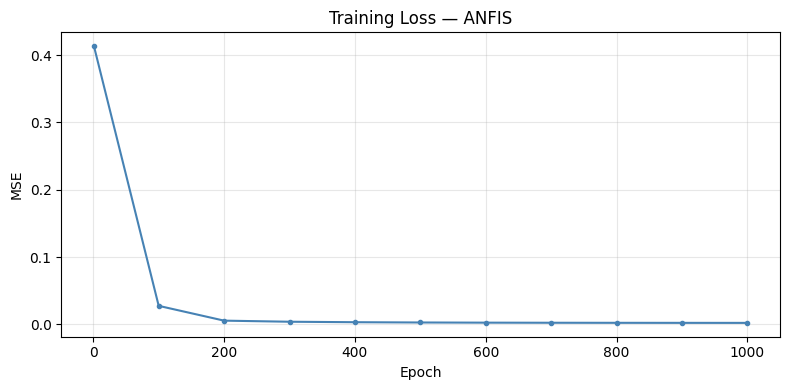

In [3]:
# ============================================================
# 1.2 — Model Instantiation and Training
# ============================================================
model_reg = ANFISModel(
    n_inputs=2,
    n_terms=5,          # 5 linguistic terms per input -> 5^2 = 25 rules
    mf_type='gaussian',
    dense_layers=None,  # scalar output directly from defuzzification
)

print("ANFIS Architecture:")
print("  Input variables :", model_reg.n_inputs)
print("  Terms per input :", model_reg.n_terms)
print("  Total rules     :", model_reg.n_rules)
print("  Total parameters:", sum(p.numel() for p in model_reg.parameters()))

optimizer = torch.optim.Adam(model_reg.parameters(), lr=2e-2)

history = train_model(
    model=model_reg,
    X_train=X_train_t,
    y_train=y_train_t,
    optimizer=optimizer,
    loss_name='mse',
    epochs=1000,
    print_every=100,
)

plot_training_history(history, loss_name='mse')


Test MSE: 0.002664
Test MAE: 0.040892


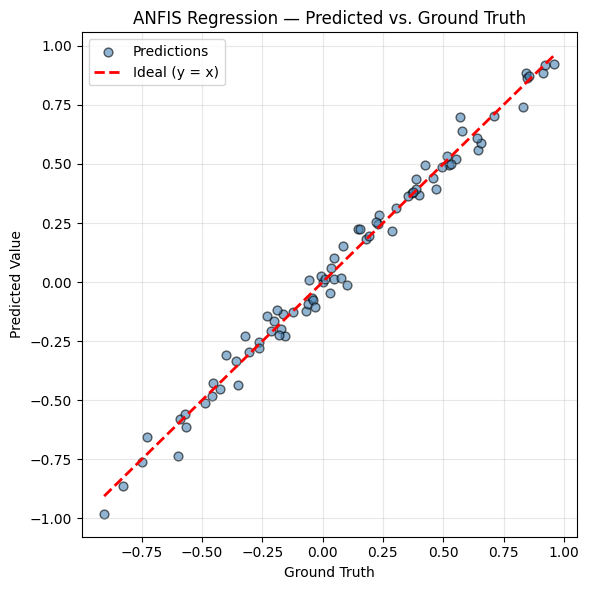

In [4]:
# ============================================================
# 1.3 — Test Set Evaluation
# ============================================================
model_reg.eval()
with torch.no_grad():
    y_pred = model_reg(X_test_t)
    test_mse = nn.functional.mse_loss(y_pred, y_test_t).item()
    test_mae = nn.functional.l1_loss(y_pred, y_test_t).item()

print("Test MSE: {:.6f}".format(test_mse))
print("Test MAE: {:.6f}".format(test_mae))

# Predicted vs. Ground Truth scatter plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, y_pred.numpy(), alpha=0.6, c='steelblue',
           edgecolors='k', s=40, label='Predictions')
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
        'r--', lw=2, label='Ideal (y = x)')
ax.set_xlabel('Ground Truth')
ax.set_ylabel('Predicted Value')
ax.set_title('ANFIS Regression — Predicted vs. Ground Truth')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


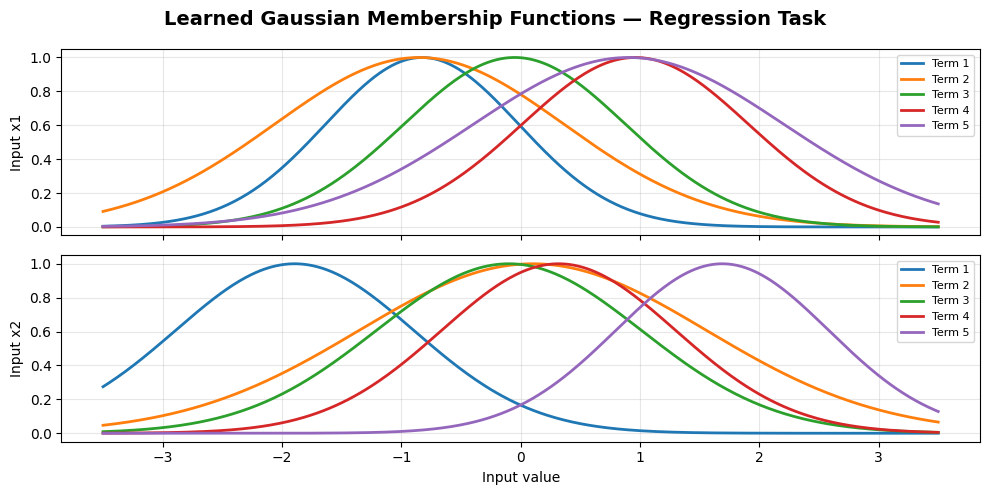

In [5]:
# ============================================================
# 1.4 — Learned Membership Function Visualization
# ============================================================
plot_membership_functions(
    model_reg,
    x_range=(-3.5, 3.5),
    title='Learned Gaussian Membership Functions — Regression Task'
)


<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\thomm\AppData\Local\Temp\ipykernel_23284\2230890491.py:8: SyntaxWarning: invalid escape sequence '\s'
  title='ANFIS Learned Surface: $\sin(x_1) \cdot \cos(x_2)$',


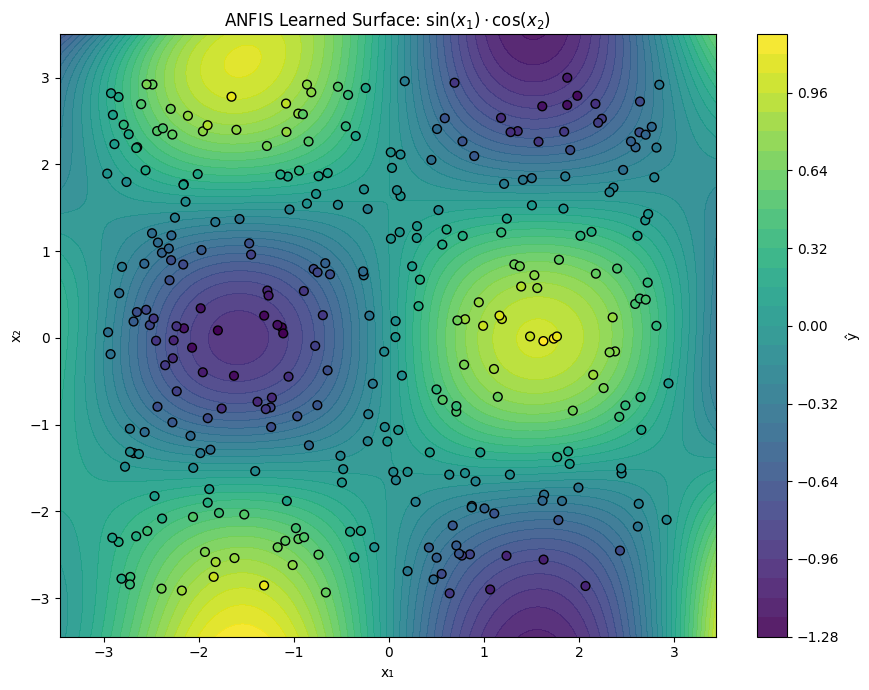

In [6]:
# ============================================================
# 1.5 — Learned Regression Surface
# ============================================================
plot_regression_surface(
    model_reg,
    X_train=X_train,
    y_train=y_train,
    title='ANFIS Learned Surface: $\sin(x_1) \cdot \cos(x_2)$',
    n_grid=200,
)


In [7]:
# ============================================================
# 1.6 — Linguistic Rule Extraction (Interpretability)
# ============================================================
sample = X_test_t[0]
print("Test sample: x1={:.3f}, x2={:.3f}".format(
    sample[0].item(), sample[1].item()))
print("Ground truth: {:.4f}".format(y_test[0].item()))

model_reg.eval()
with torch.no_grad():
    pred = model_reg(sample.unsqueeze(0)).item()
print("ANFIS prediction: {:.4f}".format(pred))
print()

explanations = model_reg.get_rule_explanation(sample, top_k=5)
print("Top-5 most active fuzzy rules:")
for exp in explanations:
    print("  IF {:<35} THEN y={:+.4f}  (strength={:.4f})".format(
        exp['antecedent'], exp['consequent'], exp['strength']))


Test sample: x1=1.035, x2=1.514
Ground truth: 0.0345
ANFIS prediction: 0.0609

Top-5 most active fuzzy rules:
  IF x1 is t3 AND x2 is t4               THEN y=-3.4434  (strength=0.1402)
  IF x1 is t4 AND x2 is t4               THEN y=+0.5768  (strength=0.1399)
  IF x1 is t3 AND x2 is t1               THEN y=-1.0906  (strength=0.0893)
  IF x1 is t4 AND x2 is t1               THEN y=+2.3210  (strength=0.0891)
  IF x1 is t2 AND x2 is t4               THEN y=-2.2278  (strength=0.0710)


In [8]:
# ============================================================
# 1.7 — Export to JSON and Generate ESP32 Arduino Code
# ============================================================
export_to_json(model_reg, 'json_model/regression_model.json')
generate_ino(
    json_path='json_model/regression_model.json',
    output_dir='arduino_code/regression_ino',
    board='esp32',
    task='regression',
)


ANFIS model exported → json_model/regression_model.json
Generated in : arduino_code/regression_ino  (board: esp32)
Verification  n_inputs=2, n_terms=5, n_rules=25
Expected output (Python) : [0.8940970301628113]


---

## 2 — Binary Classification

This section demonstrates binary classification on the classic **two-moons** dataset, which exhibits a non-convex decision boundary that linear classifiers cannot separate.


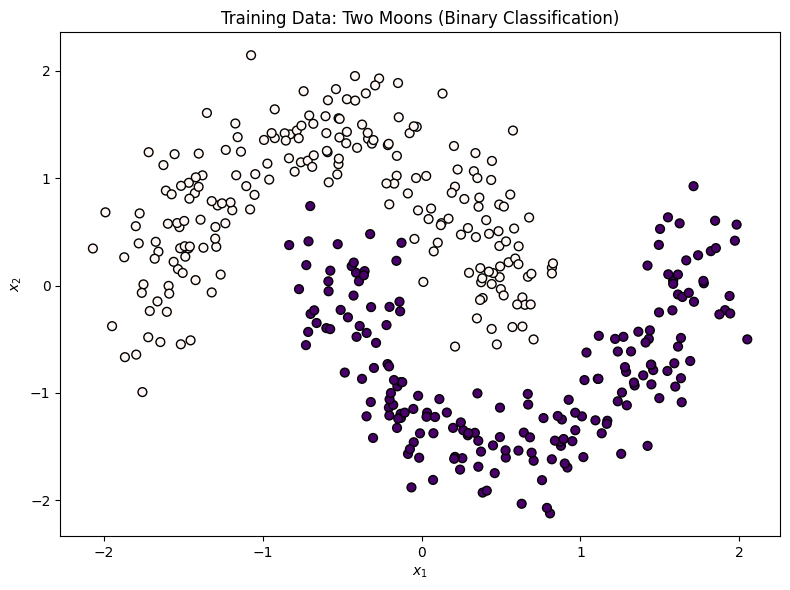

In [9]:
# ============================================================
# 2.1 — Two-Moons Dataset
# ============================================================
X, y = make_moons(n_samples=500, noise=0.15, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.float32).reshape(-1, 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train.flatten(),
           cmap='RdPu', edgecolors='k', s=40)
ax.set_title('Training Data: Two Moons (Binary Classification)')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
plt.tight_layout()
plt.show()


  Epoch     1/600  |  BCE = 0.900720
  Epoch   100/600  |  BCE = 0.211123
  Epoch   200/600  |  BCE = 0.070020
  Epoch   300/600  |  BCE = 0.036482
  Epoch   400/600  |  BCE = 0.025622
  Epoch   500/600  |  BCE = 0.019626
  Epoch   600/600  |  BCE = 0.015755


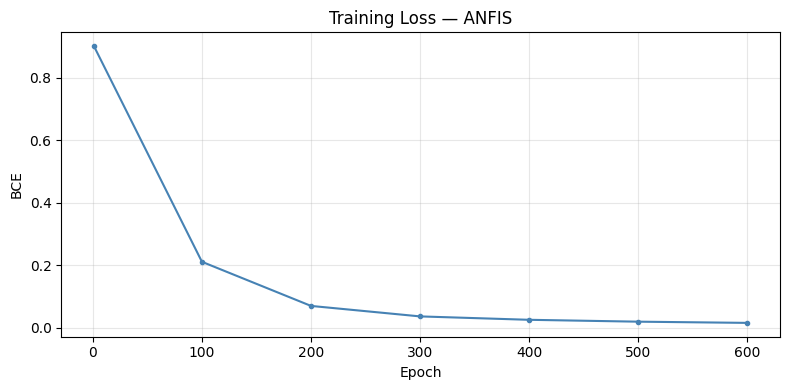

In [10]:
# ============================================================
# 2.2 — ANFIS Training for Binary Classification
# ============================================================
model_bin = ANFISModel(
    n_inputs=2,
    n_terms=4,          # 4 terms per input -> 4^2 = 16 rules
    mf_type='gaussian',
    dense_layers=None,
)

optimizer = torch.optim.Adam(model_bin.parameters(), lr=1e-2)

history = train_model(
    model=model_bin,
    X_train=X_train_t,
    y_train=y_train_t,
    optimizer=optimizer,
    loss_name='bce',     # Binary Cross-Entropy with logits
    epochs=600,
    print_every=100,
)

plot_training_history(history, loss_name='bce')


Test accuracy: 99.00%


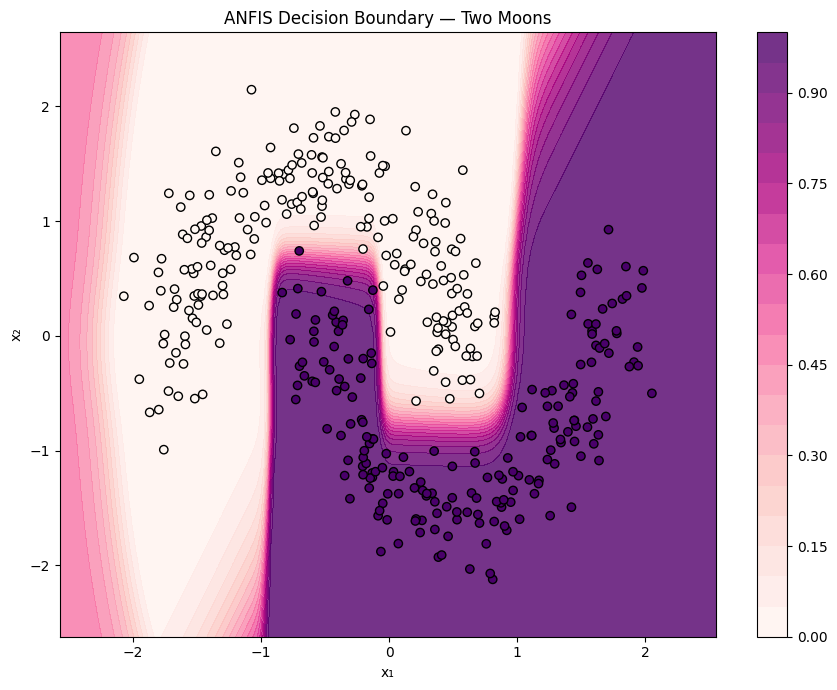

In [11]:
# ============================================================
# 2.3 — Evaluation and Decision Boundary
# ============================================================
model_bin.eval()
with torch.no_grad():
    logits = model_bin(X_test_t)
    probs = torch.sigmoid(logits)
    preds = (probs > 0.5).float()
    accuracy = (preds == y_test_t).float().mean().item()

print("Test accuracy: {:.2f}%".format(accuracy * 100))

plot_decision_boundary(
    model_bin,
    X=X_train,
    y=y_train.flatten().astype(int),
    title='ANFIS Decision Boundary — Two Moons',
    task='binary',
    n_grid=200,
)


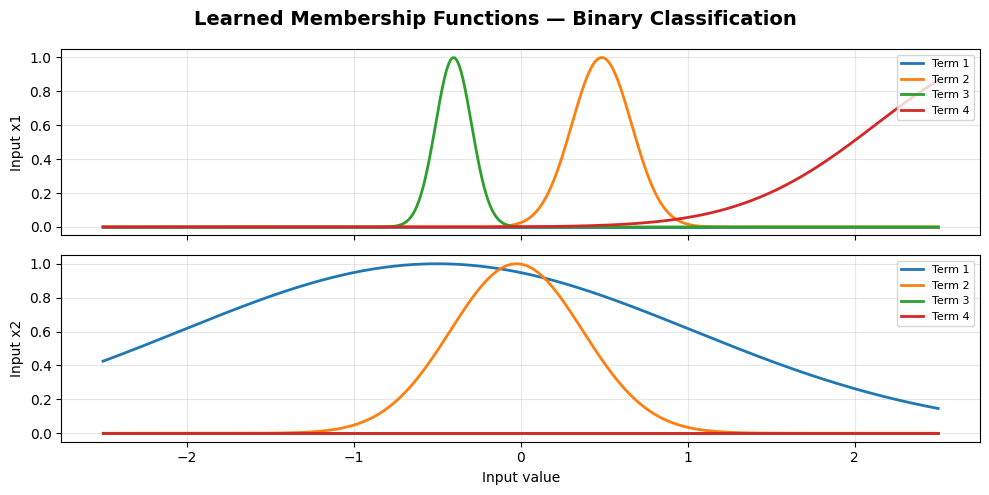

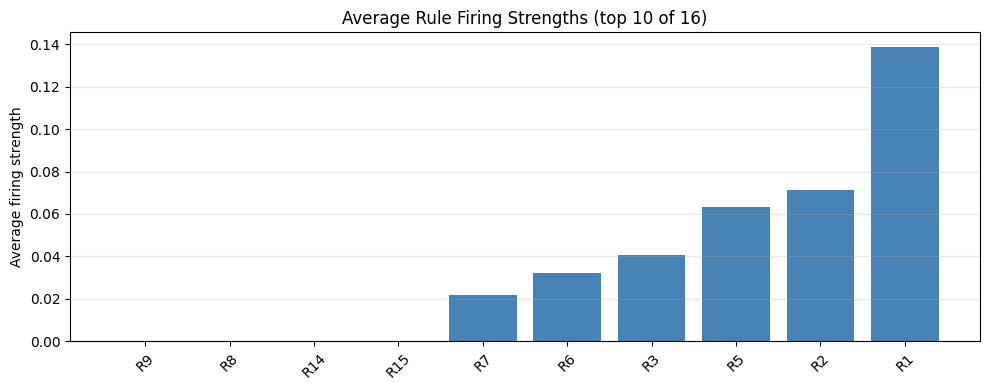

In [12]:
# ============================================================
# 2.4 — Membership Functions and Rule Firing Strengths
# ============================================================
plot_membership_functions(
    model_bin,
    x_range=(-2.5, 2.5),
    title='Learned Membership Functions — Binary Classification'
)
plot_firing_strengths(
    model_bin,
    X_train_t,
    title='Average Rule Firing Strengths',
    top_k=10
)


In [13]:
# ============================================================
# 2.5 — Export to JSON and Generate ESP32 Arduino Code
# ============================================================
export_to_json(model_bin, 'json_model/binary_model.json')
generate_ino(
    json_path='json_model/binary_model.json',
    output_dir='arduino_code/binary_ino',
    board='esp32',
    task='binary',
)


ANFIS model exported → json_model/binary_model.json
Generated in : arduino_code/binary_ino  (board: esp32)
Verification  n_inputs=2, n_terms=4, n_rules=16
Expected output (Python) : [6.059898853302002]


---

## 3 — Multiclass Classification

This section addresses a three-class problem using the `make_blobs` generator. A dense head with ReLU activation is appended after the defuzzification layer to produce three class logits.


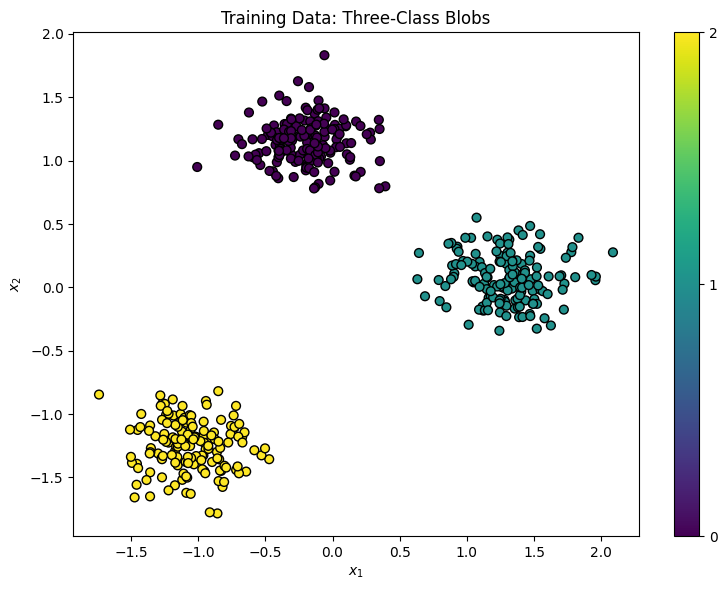

In [14]:
# ============================================================
# 3.1 — Three-Class Blob Dataset
# ============================================================
X, y = make_blobs(n_samples=600, centers=3, cluster_std=1.2, random_state=42)
X = X.astype(np.float32)
y = y.astype(np.int64)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

X_train_t = torch.from_numpy(X_train)
y_train_t = torch.from_numpy(y_train)
X_test_t  = torch.from_numpy(X_test)
y_test_t  = torch.from_numpy(y_test)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(X_train[:, 0], X_train[:, 1], c=y_train,
                     cmap='viridis', edgecolors='k', s=40)
ax.set_title('Training Data: Three-Class Blobs')
ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
plt.colorbar(scatter, ax=ax, ticks=[0, 1, 2])
plt.tight_layout()
plt.show()


Architecture:
  Fuzzy rules   : 16
  Total params  : 147
  Epoch     1/800  |  SCCE = 1.153567
  Epoch   100/800  |  SCCE = 0.003493
  Epoch   200/800  |  SCCE = 0.000720
  Epoch   300/800  |  SCCE = 0.000338
  Epoch   400/800  |  SCCE = 0.000200
  Epoch   500/800  |  SCCE = 0.000133
  Epoch   600/800  |  SCCE = 0.000095
  Epoch   700/800  |  SCCE = 0.000072
  Epoch   800/800  |  SCCE = 0.000056


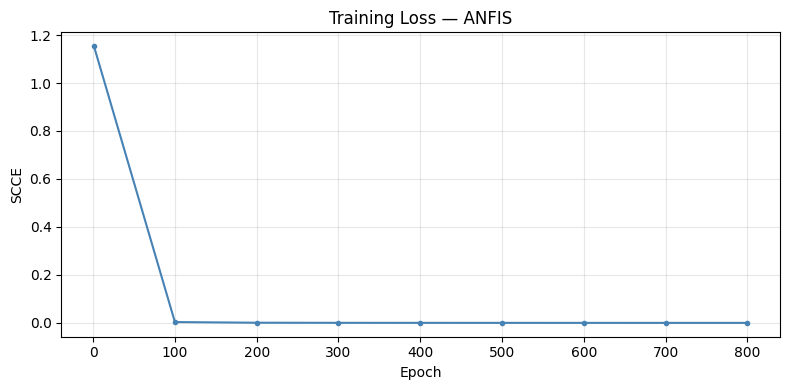

In [15]:
# ============================================================
# 3.2 — ANFIS with Dense Head for Three-Class Output
# ============================================================
model_multi = ANFISModel(
    n_inputs=2,
    n_terms=4,          # 4^2 = 16 fuzzy rules
    mf_type='gaussian',
    dense_layers=[
        {'out_features': 16, 'activation': 'relu'},
        {'out_features': 3,  'activation': 'linear'},  # 3 class logits
    ],
)

print("Architecture:")
print("  Fuzzy rules   :", model_multi.n_rules)
print("  Total params  :", sum(p.numel() for p in model_multi.parameters()))

optimizer = torch.optim.Adam(model_multi.parameters(), lr=1e-2)

history = train_model(
    model=model_multi,
    X_train=X_train_t,
    y_train=y_train_t,
    optimizer=optimizer,
    loss_name='scce',    # Sparse Categorical Cross-Entropy
    epochs=800,
    print_every=100,
)

plot_training_history(history, loss_name='scce')


Test accuracy: 100.00%


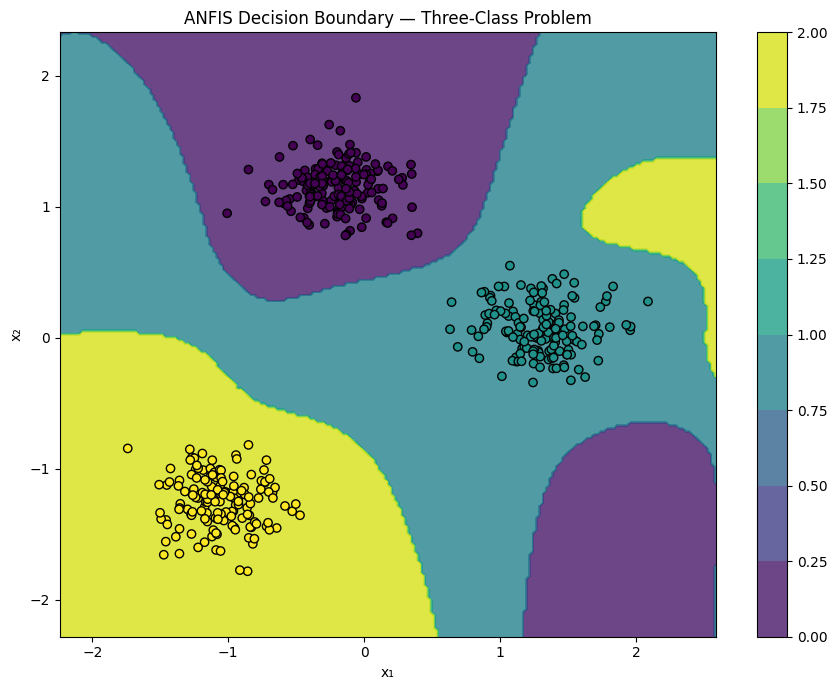

In [16]:
# ============================================================
# 3.3 — Evaluation and Decision Boundary
# ============================================================
model_multi.eval()
with torch.no_grad():
    logits = model_multi(X_test_t)
    preds = torch.argmax(logits, dim=1)
    accuracy = (preds == y_test_t).float().mean().item()

print("Test accuracy: {:.2f}%".format(accuracy * 100))

plot_decision_boundary(
    model_multi,
    X=X_train,
    y=y_train,
    title='ANFIS Decision Boundary — Three-Class Problem',
    task='multiclass',
    n_grid=200,
)


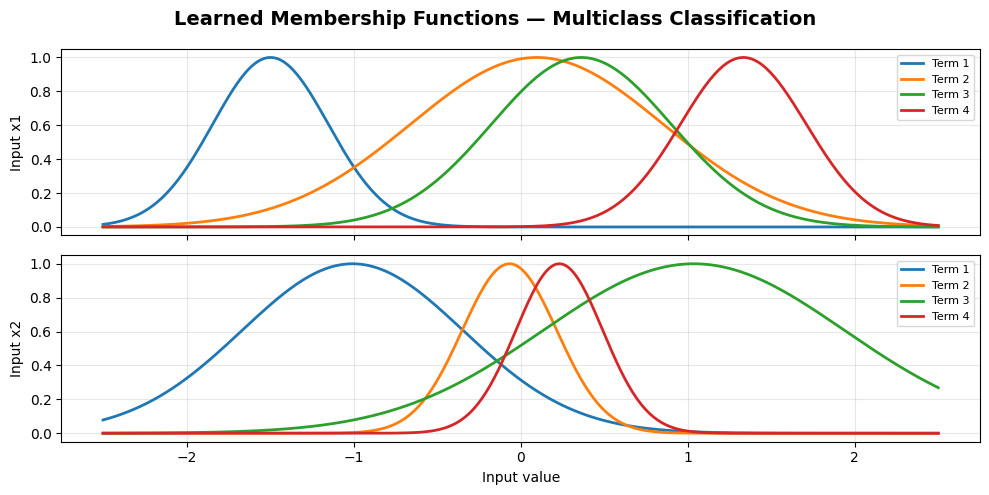

In [17]:
# ============================================================
# 3.4 — Learned Membership Functions
# ============================================================
plot_membership_functions(
    model_multi,
    x_range=(-2.5, 2.5),
    title='Learned Membership Functions — Multiclass Classification'
)


In [18]:
# ============================================================
# 3.5 — Export to JSON and Generate ESP32 Arduino Code
# ============================================================
export_to_json(model_multi, 'json_model/multiclass_model.json')
generate_ino(
    json_path='json_model/multiclass_model.json',
    output_dir='arduino_code/multiclass_ino',
    board='esp32',
    task='multiclass',
)


ANFIS model exported → json_model/multiclass_model.json
Generated in : arduino_code/multiclass_ino  (board: esp32)
Verification  n_inputs=2, n_terms=4, n_rules=16
Expected output (Python) : [-1.963385820388794, 7.477623462677002, -1.3677654266357422]


---

## 4 — Fuzzy Regularization for Interpretability

The `fuzzy_reg_loss` function penalizes:
1. **Excessive membership function width** (large $\sigma$), encouraging compact, linguistically meaningful fuzzy sets.
2. **Excessive overlap** between adjacent membership functions, promoting clear separation of linguistic terms.

This regularization improves both generalization and human interpretability of the learned rule base.


  Epoch  100/1000  |  Loss = 0.016294
  Epoch  200/1000  |  Loss = 0.007933
  Epoch  300/1000  |  Loss = 0.006442
  Epoch  400/1000  |  Loss = 0.005370
  Epoch  500/1000  |  Loss = 0.004282
  Epoch  600/1000  |  Loss = 0.003598
  Epoch  700/1000  |  Loss = 0.003028
  Epoch  800/1000  |  Loss = 0.002587
  Epoch  900/1000  |  Loss = 0.002130
  Epoch 1000/1000  |  Loss = 0.001612


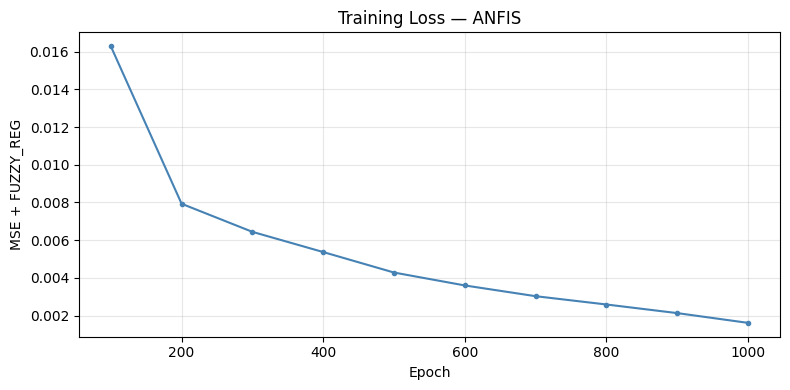

In [19]:
# Ensure tensors use floating-point dtype
X_train_t = X_train_t.float()
y_train_t = y_train_t.float()

# ============================================================
# 4.1 — Training with Fuzzy Regularization
# ============================================================
model_reg_fuzzy = ANFISModel(
    n_inputs=2,
    n_terms=5,
    mf_type='gaussian'
)

optimizer = torch.optim.Adam(
    model_reg_fuzzy.parameters(),
    lr=2e-2
)

model_reg_fuzzy.train()
history_fuzzy = []

for epoch in range(1, 1001):

    optimizer.zero_grad()

    # Forward pass
    output = model_reg_fuzzy(X_train_t)

    # Fuzzy regularized loss
    loss = fuzzy_reg_loss(
        output=output,
        target=y_train_t,
        model=model_reg_fuzzy,
        reg_weight=1e-2,      # width penalty
        overlap_pen=5e-2,     # overlap penalty
        loss_name='mse',
    )

    # Backpropagation
    loss.backward()

    # Update parameters
    optimizer.step()

    if epoch % 100 == 0:
        print(
            "  Epoch {:>4}/1000  |  Loss = {:.6f}".format(
                epoch,
                loss.item()
            )
        )

        history_fuzzy.append(
            (epoch, loss.item())
        )

plot_training_history(
    history_fuzzy,
    loss_name='mse + fuzzy_reg'
)

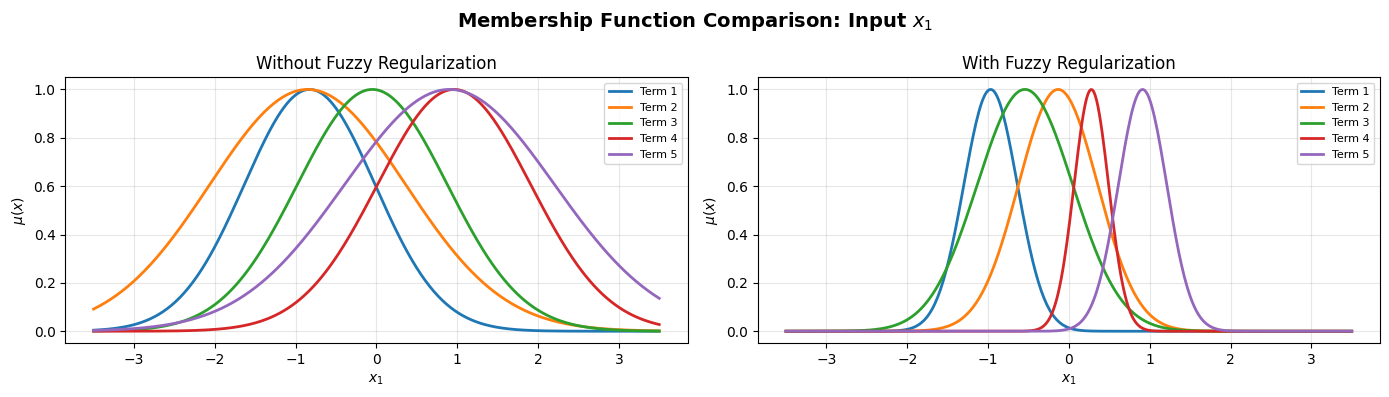

In [20]:
# ============================================================
# 4.2 — Comparison: With vs. Without Fuzzy Regularization
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x = torch.linspace(-3.5, 3.5, 400)

# Without regularization
with torch.no_grad():
    for k in range(model_reg.n_terms):
        c = model_reg.fuzzify.center[0, k]
        s = model_reg.fuzzify.sigma[0, k]
        mu = torch.exp(-0.5 * ((x - c) / s.clamp(min=1e-6)) ** 2)
        axes[0].plot(x.numpy(), mu.numpy(), lw=2, label='Term {}'.format(k + 1))
axes[0].set_title('Without Fuzzy Regularization')
axes[0].set_xlabel(r'$x_1$')
axes[0].set_ylabel(r'$\mu(x)$')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# With regularization
with torch.no_grad():
    for k in range(model_reg_fuzzy.n_terms):
        c = model_reg_fuzzy.fuzzify.center[0, k]
        s = model_reg_fuzzy.fuzzify.sigma[0, k]
        mu = torch.exp(-0.5 * ((x - c) / s.clamp(min=1e-6)) ** 2)
        axes[1].plot(x.numpy(), mu.numpy(), lw=2, label='Term {}'.format(k + 1))
axes[1].set_title('With Fuzzy Regularization')
axes[1].set_xlabel(r'$x_1$')
axes[1].set_ylabel(r'$\mu(x)$')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.suptitle('Membership Function Comparison: Input $x_1$',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

## 5 — Summary and Next Steps

| Task | Status |
|------|--------|
| Nonlinear regression | Completed |
| Binary classification | Completed |
| Multiclass classification | Completed |
| Membership function visualization | Completed |
| Linguistic rule extraction | Completed |
| JSON export (per example) | Completed |
| ESP32 Arduino code generation (per example) | Completed |
| Fuzzy regularization | Completed |

### Recommended Next Steps

1. **Adjust `n_terms`** — Increasing the number of linguistic terms raises model capacity (more rules) but also increases parameter count. For TinyML, keep $n_{\text{terms}} \leq 5$ and $n_{\text{inputs}} \leq 4$.

2. **Experiment with alternative membership functions** — Try `sigmoid` or `bell` shapes when the input domain exhibits asymmetric or open-ended concepts.

3. **Extend to higher-dimensional inputs** — ANFIS supports arbitrary $n_{\text{inputs}}$, but the rule base grows combinatorially ($n_{\text{rules}} = n_{\text{terms}}^{n_{\text{inputs}}}$). Consider dimensionality reduction (PCA) for high-dimensional problems.

4. **Hybrid architectures** — Combine ANFIS with the LTC recurrent layers from the LNN framework to obtain a model with both temporal memory and fuzzy interpretability.
